## Physical Problem

We consider **steady-state heat conduction through a heterogeneous material
with localized heat sources**.

The material occupies a 2D square domain:

$$
(x,y)\in[0,1]^2
$$

The thermal conductivity varies spatially:

$$
\kappa=\kappa(x,y)
$$

so different regions of the material conduct heat differently.

The domain also contains a number of localized heat sources (junctions).
Their positions and powers can vary from one configuration to another.

For junction $m$, we define:

$$
(x_m,y_m,P_m)
$$

where $(x_m,y_m)$ is its position and $P_m$ is its heat generation.

The resulting heat-source field is denoted by:

$$
Q=Q(x,y)
$$

At steady state, the temperature satisfies:

$$
\nabla\cdot\left(\kappa(x,y)\nabla\theta(x,y)\right)
+Q(x,y)=0
$$

The left boundary is maintained at a hot temperature, while the right
boundary is maintained at a cold temperature:

$$
\theta(0,y)=1,
\qquad
\theta(1,y)=0
$$

The top and bottom boundaries are adiabatic:

$$
\frac{\partial\theta}{\partial y}(x,0)=0,
\qquad
\frac{\partial\theta}{\partial y}(x,1)=0
$$

For each conductivity field $\kappa(x,y)$ and heat-source configuration
$Q(x,y)$, there is a corresponding temperature field $\theta(x,y)$.

The goal of DeepONet is to learn the mapping:

$$
\boxed{
(\kappa(x,y),Q(x,y))\longrightarrow\theta(x,y)
}
$$

In [1]:
import numpy as np
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt

In [ ]:
def plot_field(field, N, ax, title="", vmin=None, vmax=None,
               cmap="jet", annot=None):

    # Reshape the field into a square grid
    g = np.asarray(field).reshape(N, N)

    # Fixed normalization for dimensionless fields
    vmin = g.min() if vmin is None else vmin
    vmax = g.max() if vmax is None else vmax

    # Plot the field
    im = ax.imshow(
        g,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        origin="lower"
    )

    # Show values for small grids
    annot = (N <= 15) if annot is None else annot

    if annot:
        for r in range(N):
            for c in range(N):
                frac = g[r,c]

                # Add values to the grid cells
                ax.text(
                    c, r, f"{g[r, c]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if frac < 0.55 else "black",
                    fontsize=7
                )

    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    return im

In [ ]:
def solve(k, Q):

    k = k.T

    Q = Q.T

    N = k.shape[0]

    # Initialize the system matrix and source vector
    A = np.zeros((N*N, N*N))

    b = np.zeros(N*N)

    for i in range(N):

        for j in range(N):

            p = i + j*N

            # Left: theta = 1
            if i == 0:

                A[p, p] = 1.0

                b[p] = 0.0

                continue

            # Right: theta = 0
            if i == N-1:

                A[p, p] = 1.0

                b[p] = 0.0

                continue

            # Get the conductivity at the current cell
            kP = k[i, j]

            kE = 2*kP*k[i+1,j]/(kP+k[i+1,j])

            kW = 2*kP*k[i-1,j]/(kP+k[i-1,j])

            kN = (

                2*kP*k[i,j+1]/(kP+k[i,j+1])

                if j < N-1 else 0.0

            )

            kS = (

                2*kP*k[i,j-1]/(kP+k[i,j-1])

                if j > 0 else 0.0

            )

            aE, aW = kE, kW

            aN, aS = kN, kS

            # Compute the central coefficient
            aP = aE + aW + aN + aS

            A[p,p] = aP

            A[p,p+1] = -aE

            A[p,p-1] = -aW

            if j < N-1:

                A[p,p+N] = -aN

            if j > 0:

                A[p,p-N] = -aS

            b[p] = Q[i,j]

    # Solve the linear system
    theta = np.linalg.solve(A,b)

    return theta.reshape(N,N)

In [ ]:
def random_kappa(N, rng, high=0.7, low=0.3):

    # Number of blocks in each direction
    # We choose 2, 3, 4, 5 or 6
    nb = rng.integers(2, 7)

    # Small grid of random values
    random_values = rng.random((nb, nb))

    # Random threshold between 0.3 and 0.7
    threshold = rng.uniform(0.3, 0.7)

    # True -> high conductivity
    # False -> low conductivity
    mask = random_values < threshold

    # Approximate block size
    block_size = int(np.ceil(N / nb))

    # Block filled with 1
    block = np.ones((block_size, block_size))

    # Expand the small grid
    large_mask = np.kron(mask, block)

    # Keep exactly an N x N grid
    large_mask = large_mask[:N, :N]

    # True -> high = 1.0
    # False -> low = 0.1
    kappa = np.where(large_mask, high, low)
    return kappa

def random_sources(N, rng, n_sources=3, power_low=0.1, power_high=1.0):

    Q = np.zeros((N, N))

    for _ in range(n_sources):

        i = rng.integers(1, N - 1)

        j = rng.integers(0, N)

        power = rng.uniform(power_low, power_high)

        Q[i, j] = power

    return Q

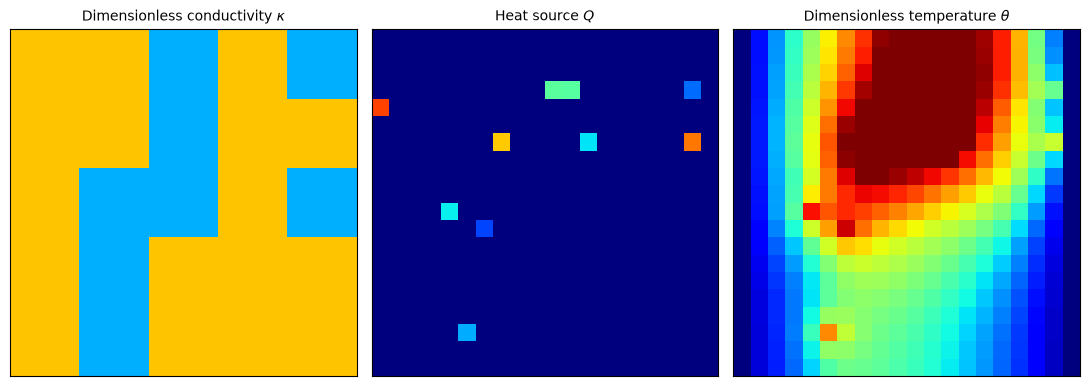

In [ ]:
N = 20

rng = np.random.default_rng(3)

# Generate the conductivity field
kappa = random_kappa(N, rng)

# Generate the heat source field
Q = random_sources(
    N,
    rng,
    n_sources=10,
    power_low=0.1,
    power_high=1.0
)

# Solve for the temperature field
theta = solve(kappa, Q)

# Create subplots for the three fields
fig, axs = plt.subplots(1, 3, figsize=(11, 3.8))

# Plot the conductivity field
plot_field(
    kappa, N, axs[0],
    r"Dimensionless conductivity $\kappa$",
    vmin=0, vmax=1,
)

# Plot the heat source field
plot_field(
    Q, N, axs[1],
    r"Heat source $Q$",
    vmin=0, vmax=1,
)

# Plot the temperature field
plot_field(
    theta, N, axs[2],
    r"Dimensionless temperature $\theta$",
    vmin=0, vmax=1,
)

plt.tight_layout()

plt.show()

In [ ]:
def mlp(input, hidden, depth, output, act=nn.GELU):

    # Build the MLP layers
    layers = [nn.Linear(input, hidden), act()] + [x for _ in range(depth - 1) for x in (nn.Linear(hidden, hidden), act())] + [nn.Linear(hidden, output)]

    # Create the sequential network
    net = nn.Sequential(*layers)

    return net

In [ ]:
class DeepONet(nn.Module):

    def __init__(self, m_sensors, p=128, width=128, depth=3):

        # Initialize the parent module
        super().__init__()

        # Build the branch network for input functions
        self.branch = mlp(2 * m_sensors, width, depth, p)

        # Build the trunk network for query coordinates
        self.trunk  = mlp(2, width, depth, p)

        # Trainable bias term
        self.b0 = nn.Parameter(torch.zeros(1))

    def forward(self, a, y):

        B = self.branch(a)      # [batch, p]

        T = self.trunk(y)       # [n_query, p]

        # Combine branch and trunk outputs
        return B @ T.T + self.b0

In [ ]:
def build_dataset(N, n_samples, rng):

    # Trunk coordinates
    x = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, x)



    # Coordinates
    coords = np.stack([X.ravel(), Y.ravel()], axis=1)

    # Input Branch k + Q
    A = np.zeros((n_samples, 2*N*N), dtype=np.float32)
    U = np.zeros((n_samples, N*N), dtype=np.float32)

    # Keep the physical fields
    K = np.zeros((n_samples, N, N), dtype=np.float32)
    Qs = np.zeros((n_samples, N, N), dtype=np.float32)

    for n in range(n_samples):

        # Conductivity
        kappa = random_kappa(N, rng)

        # Heat sources
        Q = random_sources(
            N,
            rng,
            n_sources=rng.integers(1, 5)
        )

        # Solve the temperature field
        theta = solve(kappa, Q)

        # DeepONet input
        A[n] = np.concatenate([
            kappa.ravel(),
            Q.ravel()
            ])

        # Output
        U[n] = theta.ravel()

        # Save physical fields
        K[n] = kappa
        Qs[n] = Q

    return coords, A, U, K, Qs

In [ ]:
N = 10

rng = np.random.default_rng(42)

# Build the dataset
coords, A, U, K, Qs = build_dataset(
    N=N,
    n_samples=2000,
    rng=rng
)

# Display dataset shapes
print(coords.shape)

print(A.shape)

print(U.shape)

print(K.shape)

print(Qs.shape)

(100, 2)
(2000, 200)
(2000, 100)
(2000, 10, 10)
(2000, 10, 10)


In [10]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temporary
A_train, A_temp, U_train, U_temp = train_test_split(
    A, U,
    test_size=0.30,
    random_state=42
)

# 15% validation, 15% test
A_val, A_test, U_val, U_test = train_test_split(
    A_temp, U_temp,
    test_size=0.50,
    random_state=42
)

print("Training :", A_train.shape, U_train.shape)
print("Validation:", A_val.shape, U_val.shape)
print("Test     :", A_test.shape, U_test.shape)

Training : (1400, 200) (1400, 100)
Validation: (300, 200) (300, 100)
Test     : (300, 200) (300, 100)


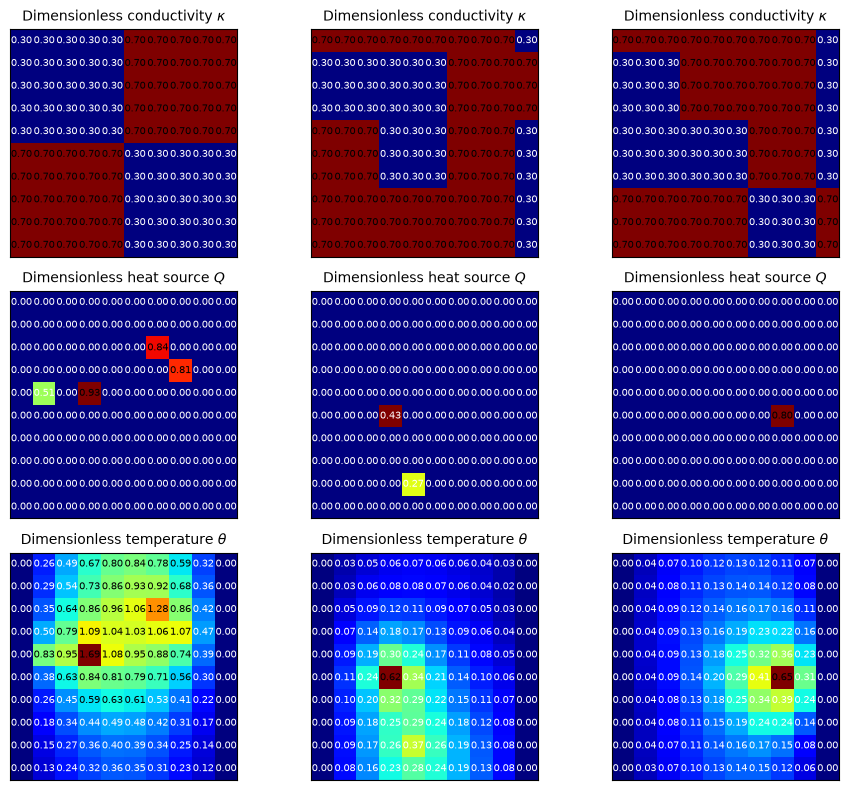

In [ ]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temporary

A_train, A_temp, U_train, U_temp = train_test_split(

    A, U,

    test_size=0.30,

    random_state=42

)

# 15% validation, 15% test

A_val, A_test, U_val, U_test = train_test_split(

    A_temp, U_temp,

    test_size=0.50,

    random_state=42

)

# Display the split sizes
print("Training :", A_train.shape, U_train.shape)

print("Validation:", A_val.shape, U_val.shape)

print("Test     :", A_test.shape, U_test.shape)

In [12]:
def rel_l2(pred, true):
    return torch.linalg.norm(pred - true) / torch.linalg.norm(true)

In [ ]:
def train_deeponet(
    model,
    At,
    Ut,
    Avt,
    Uvt,
    C,
    epochs=200,
    bs=32,
    lr=2e-3,
    seed=0,
    log_every=40
):

    # Set the random seed
    torch.manual_seed(seed)

    # Initialize optimizer and scheduler
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, epochs
    )

    # Define the loss function
    lossf = nn.MSELoss()

    train_hist = []

    val_hist = []

    for ep in range(1, epochs + 1):

        model.train()

        # Shuffle the training samples
        perm = torch.randperm(len(At))

        tot = 0.0

        nb = 0

        for i in range(0, len(At), bs):

            b = perm[i:i+bs]

            opt.zero_grad()

            pred = model(At[b], C)

            loss = lossf(pred, Ut[b])

            # Backpropagate and update the model
            loss.backward()

            opt.step()

            tot += loss.item()

            nb += 1

        sched.step()

        train_loss = tot / nb

        train_hist.append(train_loss)

        # Validation
        model.eval()

        with torch.no_grad():

            val_loss = lossf(
                model(Avt, C),
                Uvt
            ).item()

        val_hist.append(val_loss)

        # Print training progress
        if ep % log_every == 0 or ep == 1:

            print(

                f"epoch {ep:3d} | "

                f"train MSE {train_loss:.2e} | "

                f"val MSE {val_loss:.2e}"

            )

    return train_hist, val_hist

In [14]:
# Convert NumPy arrays to PyTorch tensors

At = torch.tensor(A_train, dtype=torch.float32)
Ut = torch.tensor(U_train, dtype=torch.float32)

Avt = torch.tensor(A_val, dtype=torch.float32)
Uvt = torch.tensor(U_val, dtype=torch.float32)

Att = torch.tensor(A_test, dtype=torch.float32)
Utt = torch.tensor(U_test, dtype=torch.float32)

C = torch.tensor(coords, dtype=torch.float32)

In [15]:
EPOCHS = 5000

model = DeepONet(
    m_sensors=N*N,
    p=128,
    width=128,
    depth=2
)

t0 = time.time()

hist_train, hist_val = train_deeponet(
    model,
    At,
    Ut,
    Avt,
    Uvt,
    C,
    epochs=EPOCHS,
    bs=64,
    lr=2e-3
)

print(f"trained {EPOCHS} epochs in {time.time()-t0:.0f}s")

model.eval()

with torch.no_grad():
    print(
        "validation relative L2:",
        round(rel_l2(model(Avt, C), Uvt).item(), 4)
    )

epoch   1 | train MSE 6.11e-02 | val MSE 5.44e-02
epoch  40 | train MSE 7.10e-03 | val MSE 7.35e-03
epoch  80 | train MSE 4.98e-03 | val MSE 5.41e-03
epoch 120 | train MSE 3.87e-03 | val MSE 4.35e-03
epoch 160 | train MSE 3.36e-03 | val MSE 3.86e-03
epoch 200 | train MSE 2.82e-03 | val MSE 3.29e-03
epoch 240 | train MSE 2.67e-03 | val MSE 3.29e-03
epoch 280 | train MSE 2.49e-03 | val MSE 2.90e-03
epoch 320 | train MSE 2.52e-03 | val MSE 2.97e-03
epoch 360 | train MSE 2.08e-03 | val MSE 2.47e-03
epoch 400 | train MSE 1.90e-03 | val MSE 2.37e-03
epoch 440 | train MSE 1.82e-03 | val MSE 2.25e-03
epoch 480 | train MSE 1.74e-03 | val MSE 2.24e-03
epoch 520 | train MSE 1.59e-03 | val MSE 2.00e-03
epoch 560 | train MSE 1.57e-03 | val MSE 1.98e-03
epoch 600 | train MSE 1.54e-03 | val MSE 1.97e-03
epoch 640 | train MSE 1.58e-03 | val MSE 2.04e-03
epoch 680 | train MSE 1.45e-03 | val MSE 1.92e-03
epoch 720 | train MSE 1.33e-03 | val MSE 1.80e-03
epoch 760 | train MSE 1.27e-03 | val MSE 1.72e-03


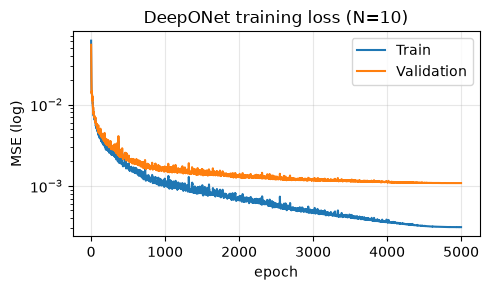

In [16]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.semilogy(hist_train, label="Train")
ax.semilogy(hist_val, label="Validation")

ax.set_xlabel("epoch")
ax.set_ylabel("MSE (log)")
ax.set_title(f"DeepONet training loss (N={N})")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
def compare(ref, pred, N, main=""):
    
    ref = ref.reshape(N, N)
    pred = pred.reshape(N, N)
    error = np.abs(pred - ref)

    fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))

    im0 = axs[0].imshow(ref, origin="lower")
    axs[0].set_title("Reference")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(pred, origin="lower")
    axs[1].set_title("DeepONet")
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(error, origin="lower")
    axs[2].set_title("Absolute error")
    plt.colorbar(im2, ax=axs[2])

    fig.suptitle(main)
    plt.tight_layout()
    plt.show()

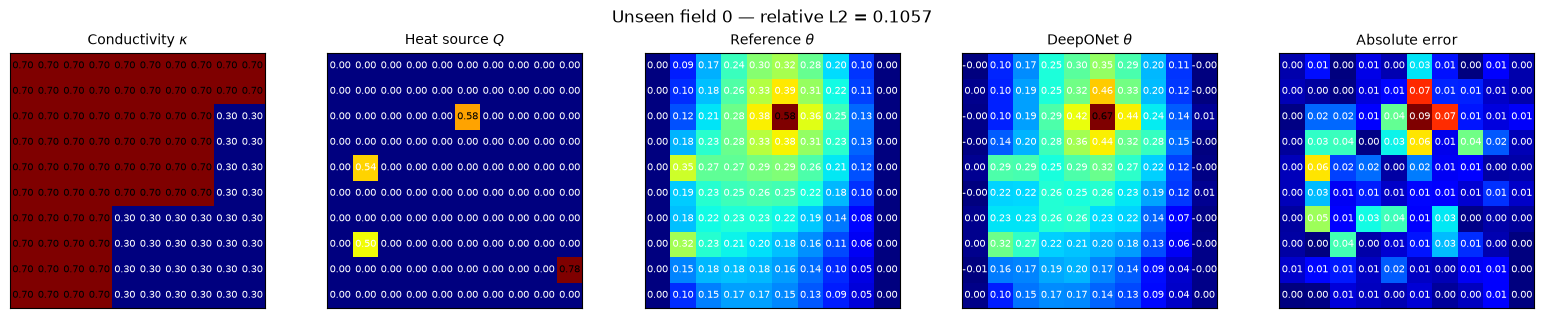

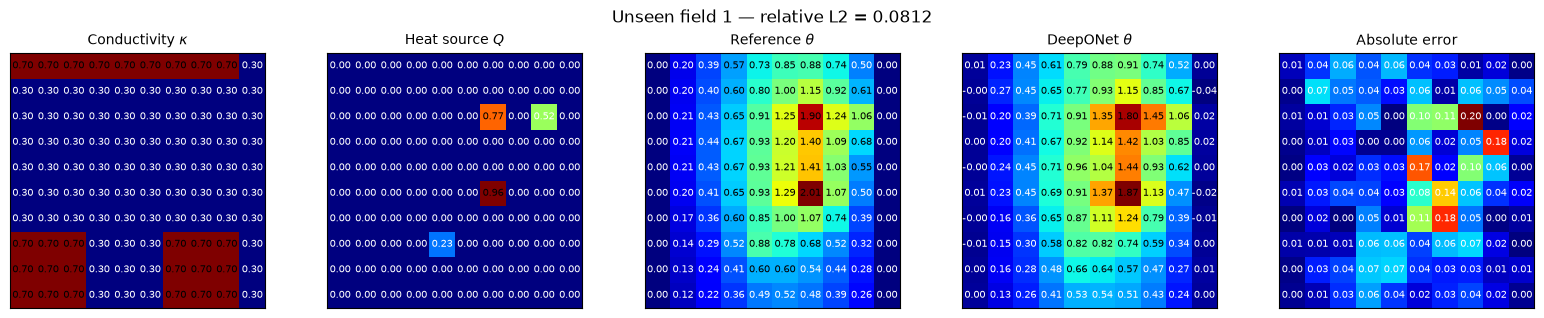

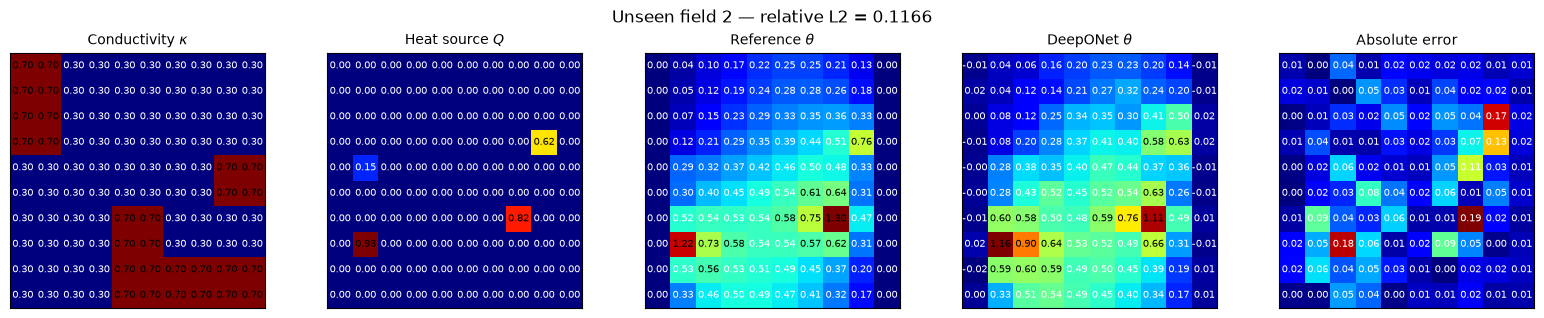

In [18]:
# Predict three unseen test fields and visualize kappa, Q, theta and error

for smp in [0, 1, 2]:

    # Input fields
    sample = Att[smp].numpy()

    kappa = sample[:N*N].reshape(N, N)
    Q = sample[N*N:].reshape(N, N)

    # Prediction
    with torch.no_grad():
        pred = model(Att[smp:smp+1], C)[0].numpy()

    ref = Utt[smp].numpy()

    # Error
    error = np.abs(pred - ref)

    # Relative L2
    rel_error = np.linalg.norm(pred - ref) / np.linalg.norm(ref)

    # Plot
    fig, axs = plt.subplots(1, 5, figsize=(16, 3.2))

    plot_field(
        kappa, N, axs[0],
        r"Conductivity $\kappa$"
    )

    plot_field(
        Q, N, axs[1],
        r"Heat source $Q$"
    )

    plot_field(
        ref, N, axs[2],
        r"Reference $\theta$"
    )

    plot_field(
        pred, N, axs[3],
        r"DeepONet $\theta$"
    )

    plot_field(
        error, N, axs[4],
        r"Absolute error"
    )

    fig.suptitle(
        f"Unseen field {smp} — relative L2 = {rel_error:.4f}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()